Image loaded: 285x177 pixels
[[127 127 128 ... 139 139 139]
 [127 127 127 ... 139 139 139]
 [127 127 127 ... 138 138 138]
 ...
 [ 45  47  50 ...  47  47  47]
 [ 56  52  47 ...  61  61  61]
 [ 58  57  49 ...  58  60  61]]


array([[127, 127, 128, ..., 139, 139, 139],
       [127, 127, 127, ..., 139, 139, 139],
       [127, 127, 127, ..., 138, 138, 138],
       ...,
       [ 45,  47,  50, ...,  47,  47,  47],
       [ 56,  52,  47, ...,  61,  61,  61],
       [ 58,  57,  49, ...,  58,  60,  61]], dtype=uint8)
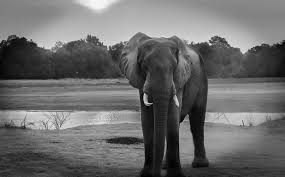

In [37]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('images.jpg', cv2.IMREAD_GRAYSCALE)

if img is None:
    print("Error: Could not find image. Check the file path!")
else:
    height, width = img.shape
    print(f"Image loaded: {width}x{height} pixels")

print(img)
img

In [38]:
#2. Initialize histogram with zeros
hist = np.zeros(256, dtype=int)
hist

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [39]:
#3.count frequency
for row in img:
    for pixel in row:
        hist[pixel] += 1

In [40]:
# 4. Normalize (Probability Density Function)
total_pixels = height * width
pdf = hist / total_pixels
total_pixels
pdf

array([1.18941421e-04, 2.57706413e-04, 2.18059272e-04, 3.37000694e-04,
       3.76647834e-04, 4.55942115e-04, 5.94707107e-04, 7.53295669e-04,
       9.11884230e-04, 9.71354941e-04, 8.92060660e-04, 1.34800278e-03,
       2.53741699e-03, 2.63653484e-03, 3.15194767e-03, 2.67618198e-03,
       3.27088909e-03, 3.37000694e-03, 3.03300624e-03, 2.99335910e-03,
       2.47794628e-03, 3.50877193e-03, 3.50877193e-03, 4.10347904e-03,
       2.93388839e-03, 3.38983051e-03, 3.52859550e-03, 3.52859550e-03,
       3.90524333e-03, 3.35018337e-03, 3.21141838e-03, 3.56824264e-03,
       3.46912479e-03, 4.04400833e-03, 3.48894836e-03, 3.70700763e-03,
       4.53959758e-03, 4.69818614e-03, 4.12330261e-03, 4.71800971e-03,
       5.64971751e-03, 5.92724750e-03, 5.66954108e-03, 5.68936465e-03,
       6.00654178e-03, 6.24442462e-03, 6.38318961e-03, 7.17613242e-03,
       7.15630885e-03, 7.33472098e-03, 6.81930816e-03, 6.56160174e-03,
       6.81930816e-03, 6.74001388e-03, 6.85895530e-03, 5.92724750e-03,
      

In [41]:
# 5. Compute Cumulative Distribution Function (CDF)
cdf = np.zeros(256)
cumulative_sum = 0
for i in range(256):
    cumulative_sum += pdf[i]
    cdf[i] = cumulative_sum
cdf


array([1.18941421e-04, 3.76647834e-04, 5.94707107e-04, 9.31707801e-04,
       1.30835563e-03, 1.76429775e-03, 2.35900486e-03, 3.11230053e-03,
       4.02418476e-03, 4.99553970e-03, 5.88760036e-03, 7.23560313e-03,
       9.77302012e-03, 1.24095550e-02, 1.55615026e-02, 1.82376846e-02,
       2.15085737e-02, 2.48785806e-02, 2.79115869e-02, 3.09049460e-02,
       3.33828923e-02, 3.68916642e-02, 4.04004361e-02, 4.45039152e-02,
       4.74378035e-02, 5.08276341e-02, 5.43562296e-02, 5.78848251e-02,
       6.17900684e-02, 6.51402518e-02, 6.83516701e-02, 7.19199128e-02,
       7.53890376e-02, 7.94330459e-02, 8.29219943e-02, 8.66290019e-02,
       9.11685995e-02, 9.58667856e-02, 9.99900882e-02, 1.04708098e-01,
       1.10357815e-01, 1.16285063e-01, 1.21954604e-01, 1.27643969e-01,
       1.33650510e-01, 1.39894935e-01, 1.46278125e-01, 1.53454257e-01,
       1.60610566e-01, 1.67945287e-01, 1.74764595e-01, 1.81326197e-01,
       1.88145505e-01, 1.94885519e-01, 2.01744474e-01, 2.07671722e-01,
      

In [42]:
new_values = np.zeros(256, dtype=np.uint8)
for i in range(256):
    new_values[i] = round(255 * cdf[i])

new_values

array([  0,   0,   0,   0,   0,   0,   1,   1,   1,   1,   2,   2,   2,
         3,   4,   5,   5,   6,   7,   8,   9,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        27,  28,  30,  31,  33,  34,  36,  37,  39,  41,  43,  45,  46,
        48,  50,  51,  53,  54,  56,  58,  59,  61,  62,  64,  65,  67,
        69,  70,  72,  73,  75,  76,  78,  79,  81,  82,  83,  85,  86,
        88,  89,  91,  92,  93,  95,  96,  98,  99, 100, 102, 103, 104,
       105, 107, 108, 109, 110, 112, 113, 114, 115, 116, 117, 118, 120,
       121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 133, 134,
       135, 136, 138, 139, 140, 142, 143, 144, 146, 147, 149, 152, 154,
       157, 160, 162, 165, 167, 170, 173, 176, 178, 180, 182, 183, 185,
       187, 188, 190, 191, 193, 194, 195, 197, 198, 200, 201, 203, 204,
       205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217,
       218, 219, 220, 221, 222, 224, 225, 226, 227, 228, 229, 23

In [43]:
equalized_img = np.zeros((height, width), dtype=np.uint8)

for r in range(height):
    for c in range(width):
        old_pixel = img[r, c]
        equalized_img[r, c] = new_values[old_pixel]

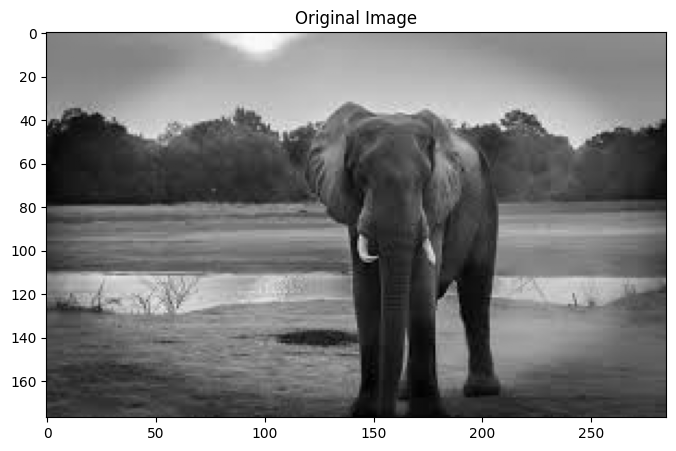

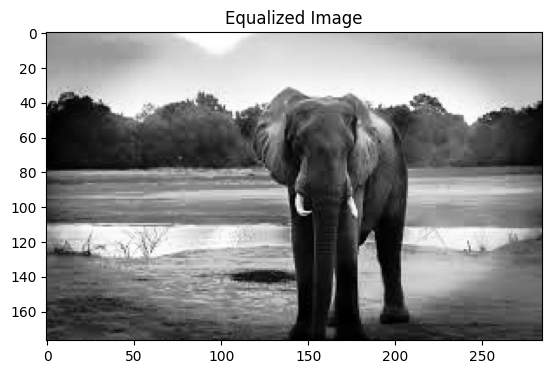

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.show()


plt.imshow(equalized_img, cmap='gray')
plt.title('Equalized Image')
plt.show()